In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
# Inspect the datasets and their shapes in the training HDF5 file

import h5py

with h5py.File(training_path, "r") as f:
    print("Number of datasets:", len(f.keys()))
    
    for key in f.keys():
        print(f"{key:45} {f[key].shape}")

NameError: name 'training_path' is not defined

In [4]:
# Select the training HDF5 file

from tkinter import Tk, filedialog

Tk().withdraw()

training_path = filedialog.askopenfilename(
    title="5x64x64_training_with_morphology",
    filetypes=[("HDF5 files", "*.hdf5 *.h5")]
)

print("Training file:", training_path)

Training file: C:/Users/ancha/Downloads/5x64x64_training_with_morphology.hdf5


In [5]:
# Check the shape and data type of the training image dataset

with h5py.File(training_path, "r") as f:
    print("Image shape:", f["image"].shape)
    print("Image data type:", f["image"].dtype)

Image shape: (204573, 5, 64, 64)
Image data type: float32


In [6]:
# Load 1D metadata features from the training HDF5 file
# The large image dataset is excluded to avoid excessive memory usage

training_metadata = {}

with h5py.File(training_path, "r") as f:
    for key in f.keys():
        if key == "image":
            continue
        
        # Include only 1-dimensional datasets
        if len(f[key].shape) == 1:
            training_metadata[key] = f[key][:]

df_train = pd.DataFrame(training_metadata)

print("Training dataset shape:", df_train.shape)
print("Number of galaxies:", len(df_train))
print("Number of features:", len(df_train.columns))

Training dataset shape: (204573, 84)
Number of galaxies: 204573
Number of features: 84


In [6]:
# Display the structure, data types and non-null values

df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204573 entries, 0 to 204572
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   coord                         204573 non-null  object 
 1   dec                           204573 non-null  float64
 2   g_central_image_pop_10px_rad  204573 non-null  int64  
 3   g_central_image_pop_15px_rad  204573 non-null  int64  
 4   g_central_image_pop_5px_rad   204573 non-null  int64  
 5   g_cmodel_mag                  204573 non-null  float64
 6   g_cmodel_magsigma             204573 non-null  float64
 7   g_ellipticity                 204573 non-null  float64
 8   g_half_light_radius           204573 non-null  float64
 9   g_isophotal_area              204573 non-null  float64
 10  g_major_axis                  204573 non-null  float64
 11  g_minor_axis                  204573 non-null  float64
 12  g_peak_surface_brightness     204573 non-nul

In [7]:
# Display the first five rows of the training dataset

display(df_train.head())

,coord,dec,g_central_image_pop_10px_rad,g_central_image_pop_15px_rad,g_central_image_pop_5px_rad,g_cmodel_mag,g_cmodel_magsigma,g_ellipticity,g_half_light_radius,g_isophotal_area,...,z_cmodel_magsigma,z_ellipticity,z_half_light_radius,z_isophotal_area,z_major_axis,z_minor_axis,z_peak_surface_brightness,z_petro_rad,z_pos_angle,z_sersic_index
0,"b'(179028.65625, 99644.3671875, -23767.86328125)'",-6.616883,1,1,1,20.162785,0.002381,0.026,2.085,177.0,...,0.002657,0.076,2.186,127.0,2.112,1.951,-8.0189,4.62,63.61,1.146
1,"b'(178895.09375, 99811.6484375, -24069.6933593...",-6.701294,1,1,1,20.320715,0.005252,0.143,5.986,327.0,...,0.002538,0.129,6.270,547.0,5.043,4.393,-7.6611,6.60,74.63,1.576
2,"b'(178918, 99992.578125, -23130.162109375)'",-6.438588,1,1,1,21.629736,0.013312,0.068,7.286,162.0,...,0.002606,0.082,6.687,611.0,5.370,4.932,-7.2715,7.26,83.77,2.096
3,"b'(179111.03125, 99659.84375, -23072.220703125)'",-6.422391,1,1,1,21.448307,0.004646,0.012,2.108,109.0,...,0.005510,0.023,2.966,121.0,2.323,2.269,-6.8408,6.60,29.82,1.943
4,"b'(178849.21875, 99990.828125, -23663.556640625)'",-6.587715,1,1,1,21.827169,0.010504,0.150,4.552,113.0,...,0.003021,0.256,5.264,401.0,4.652,3.463,-7.2982,7.26,66.69,2.187


In [8]:
# Display all column names

print("Columns:")
for col in df_train.columns:
    print(col)

Columns:
coord
dec
g_central_image_pop_10px_rad
g_central_image_pop_15px_rad
g_central_image_pop_5px_rad
g_cmodel_mag
g_cmodel_magsigma
g_ellipticity
g_half_light_radius
g_isophotal_area
g_major_axis
g_minor_axis
g_peak_surface_brightness
g_petro_rad
g_pos_angle
g_sersic_index
i_central_image_pop_10px_rad
i_central_image_pop_15px_rad
i_central_image_pop_5px_rad
i_cmodel_mag
i_cmodel_magsigma
i_ellipticity
i_half_light_radius
i_isophotal_area
i_major_axis
i_minor_axis
i_peak_surface_brightness
i_petro_rad
i_pos_angle
i_sersic_index
object_id
r_central_image_pop_10px_rad
r_central_image_pop_15px_rad
r_central_image_pop_5px_rad
r_cmodel_mag
r_cmodel_magsigma
r_ellipticity
r_half_light_radius
r_isophotal_area
r_major_axis
r_minor_axis
r_peak_surface_brightness
r_petro_rad
r_pos_angle
r_sersic_index
ra
skymap_id
specz_dec
specz_flag_homogeneous
specz_mag_i
specz_name
specz_ra
specz_redshift
specz_redshift_err
x_coord
y_central_image_pop_10px_rad
y_central_image_pop_15px_rad
y_central_image_

In [9]:
# Check for missing values in the training dataset

missing_train = df_train.isnull().sum()

print("Total missing values:", missing_train.sum())

missing_train = missing_train[missing_train > 0]

display(missing_train)

Total missing values: 0


Series([], dtype: int64)

In [10]:
# Check for duplicate rows in the training dataset

duplicates_train = df_train.duplicated().sum()

print("Duplicate rows:", duplicates_train)

Duplicate rows: 0


In [11]:
# Check for infinite values in numerical features

numeric_train = df_train.select_dtypes(include=np.number)

inf_values_train = np.isinf(numeric_train).sum().sum()

print("Infinite values:", inf_values_train)

Infinite values: 0


In [13]:
# Generate descriptive statistics for the training dataset

summary_train = df_train.describe().T

display(summary_train)
# Display minimum, maximum, mean and standard deviation

display(
    summary_train[['min', 'max', 'mean', 'std']]
)

,count,mean,std,min,25%,50%,75%,max
dec,204573.0,4.819285,14.836012,-7.227071,-0.963948,0.325055,1.724730,53.259826
g_central_image_pop_10px_rad,204573.0,1.015862,0.201299,0.000000,1.000000,1.000000,1.000000,3.000000
g_central_image_pop_15px_rad,204573.0,1.033543,0.242275,0.000000,1.000000,1.000000,1.000000,4.000000
g_central_image_pop_5px_rad,204573.0,0.998133,0.158129,0.000000,1.000000,1.000000,1.000000,3.000000
g_cmodel_mag,204573.0,21.256327,1.888613,14.365486,19.719109,21.503017,22.624615,29.835554
...,...,...,...,...,...,...,...,...
z_minor_axis,204573.0,4.060182,2.153258,0.000000,2.302000,3.726000,5.253000,16.890000
z_peak_surface_brightness,204573.0,-6.812149,1.429269,-10.623000,-7.827900,-6.994000,-5.919700,0.000000
z_petro_rad,204573.0,6.257465,1.410914,0.000000,5.280000,5.940000,6.600000,10.560000
z_pos_angle,204573.0,1.829148,52.351394,-90.000000,-43.810000,3.600000,47.470000,90.000000


,min,max,mean,std
dec,-7.227071,53.259826,4.819285,14.836012
g_central_image_pop_10px_rad,0.000000,3.000000,1.015862,0.201299
g_central_image_pop_15px_rad,0.000000,4.000000,1.033543,0.242275
g_central_image_pop_5px_rad,0.000000,3.000000,0.998133,0.158129
g_cmodel_mag,14.365486,29.835554,21.256327,1.888613
...,...,...,...,...
z_minor_axis,0.000000,16.890000,4.060182,2.153258
z_peak_surface_brightness,-10.623000,0.000000,-6.812149,1.429269
z_petro_rad,0.000000,10.560000,6.257465,1.410914
z_pos_angle,-90.000000,90.000000,1.829148,52.351394


In [14]:
# Select important photometric and morphological features

bands = ["g", "r", "i", "z", "y"]

important_features = [
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
    
    "g_ellipticity",
    "r_ellipticity",
    "i_ellipticity",
    "z_ellipticity",
    "y_ellipticity",
    
    "g_half_light_radius",
    "r_half_light_radius",
    "i_half_light_radius",
    "z_half_light_radius",
    "y_half_light_radius",
    
    "g_sersic_index",
    "r_sersic_index",
    "i_sersic_index",
    "z_sersic_index",
    "y_sersic_index",
    
    "specz_redshift"
]

display(df_train[important_features].describe().T)

,count,mean,std,min,25%,50%,75%,max
g_cmodel_mag,204573.0,21.256327,1.888613,14.365486,19.719109,21.503017,22.624615,29.835554
r_cmodel_mag,204573.0,20.246424,1.880042,13.768898,18.773922,20.309673,21.579090,30.006908
i_cmodel_mag,204573.0,19.633747,1.848060,13.376333,18.263514,19.507687,20.993273,27.931854
z_cmodel_mag,204573.0,19.325146,1.848819,13.123674,17.973379,19.136146,20.717060,28.985821
y_cmodel_mag,204573.0,19.153789,1.871167,12.939251,17.789887,18.939899,20.572125,33.529446
g_ellipticity,204573.0,0.229963,0.171878,0.000000,0.094000,0.189000,0.328000,0.976000
r_ellipticity,204573.0,0.231136,0.168788,0.000000,0.097000,0.193000,0.326000,0.917000
i_ellipticity,204573.0,0.242455,0.171246,0.000000,0.107000,0.207000,0.342000,0.936000
z_ellipticity,204573.0,0.231929,0.167484,0.000000,0.099000,0.195000,0.326000,0.933000
y_ellipticity,204573.0,0.226669,0.165807,0.000000,0.097000,0.188000,0.319000,0.926000


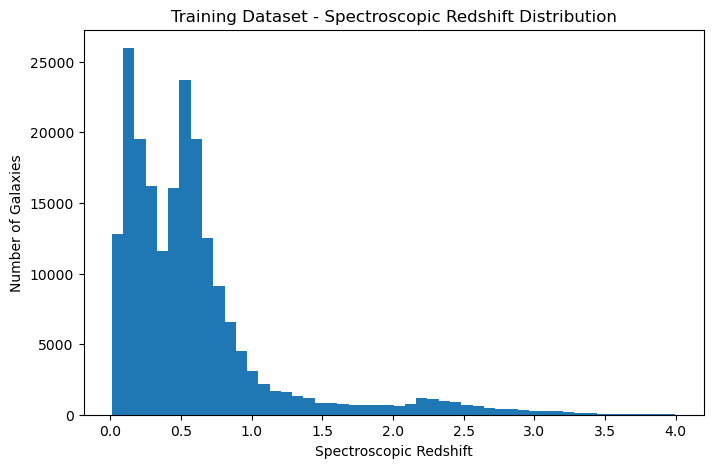

In [15]:
# Plot the distribution of spectroscopic redshift

plt.figure(figsize=(8,5))

plt.hist(
    df_train["specz_redshift"].dropna(),
    bins=50
)

plt.xlabel("Spectroscopic Redshift")
plt.ylabel("Number of Galaxies")
plt.title("Training Dataset - Spectroscopic Redshift Distribution")

plt.show()

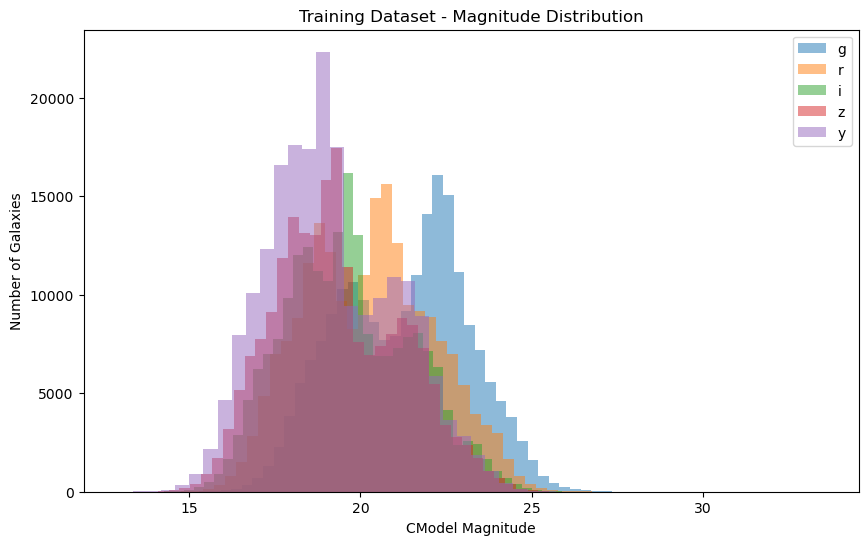

In [16]:
# Compare CModel magnitude distributions across the five photometric bands

plt.figure(figsize=(10,6))

for band in bands:
    plt.hist(
        df_train[f"{band}_cmodel_mag"].dropna(),
        bins=50,
        alpha=0.5,
        label=band
    )

plt.xlabel("CModel Magnitude")
plt.ylabel("Number of Galaxies")
plt.title("Training Dataset - Magnitude Distribution")
plt.legend()

plt.show()

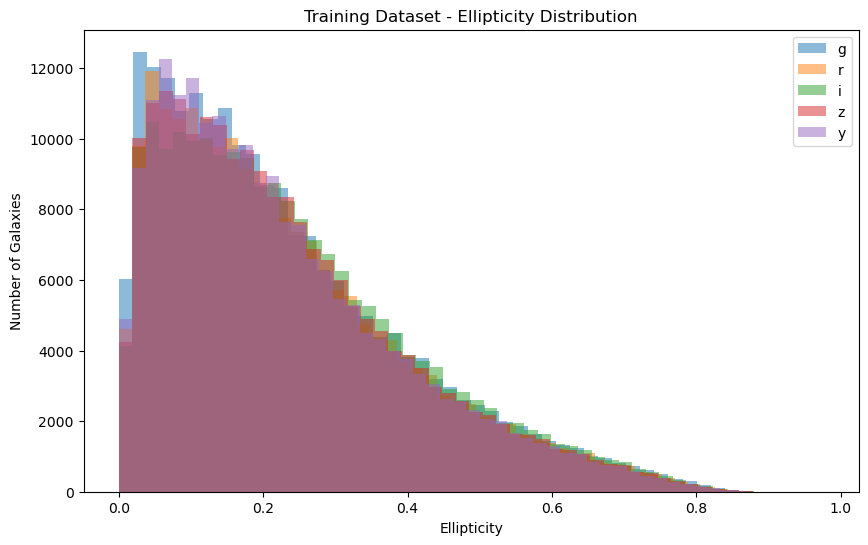

In [17]:
# Compare ellipticity distributions across the five photometric bands

plt.figure(figsize=(10,6))

for band in bands:
    plt.hist(
        df_train[f"{band}_ellipticity"].dropna(),
        bins=50,
        alpha=0.5,
        label=band
    )

plt.xlabel("Ellipticity")
plt.ylabel("Number of Galaxies")
plt.title("Training Dataset - Ellipticity Distribution")
plt.legend()

plt.show()

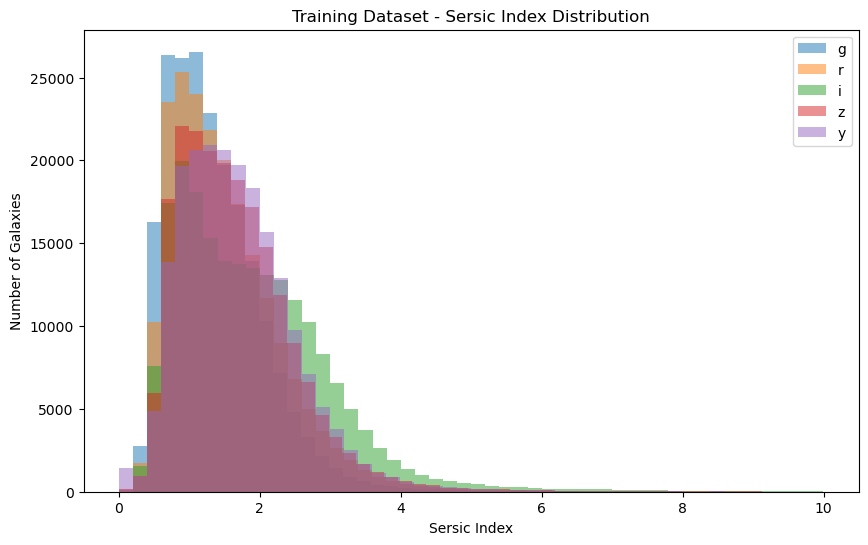

In [18]:
# Compare Sersic index distributions across the five photometric bands

plt.figure(figsize=(10,6))

for band in bands:
    plt.hist(
        df_train[f"{band}_sersic_index"].dropna(),
        bins=50,
        alpha=0.5,
        label=band
    )

plt.xlabel("Sersic Index")
plt.ylabel("Number of Galaxies")
plt.title("Training Dataset - Sersic Index Distribution")
plt.legend()

plt.show()

C:\Users\ancha\AppData\Local\Temp\ipykernel_5576\1777418267.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


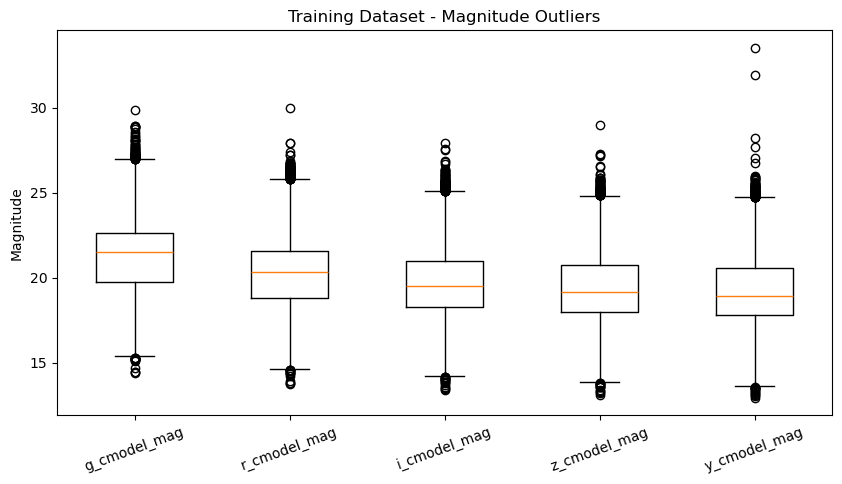

In [19]:
# Use boxplots to identify potential outliers in galaxy magnitudes

magnitude_cols = [f"{b}_cmodel_mag" for b in bands]

plt.figure(figsize=(10,5))

plt.boxplot(
    [df_train[col] for col in magnitude_cols],
    labels=magnitude_cols
)

plt.xticks(rotation=20)
plt.ylabel("Magnitude")
plt.title("Training Dataset - Magnitude Outliers")

plt.show()

C:\Users\ancha\AppData\Local\Temp\ipykernel_5576\4157245493.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


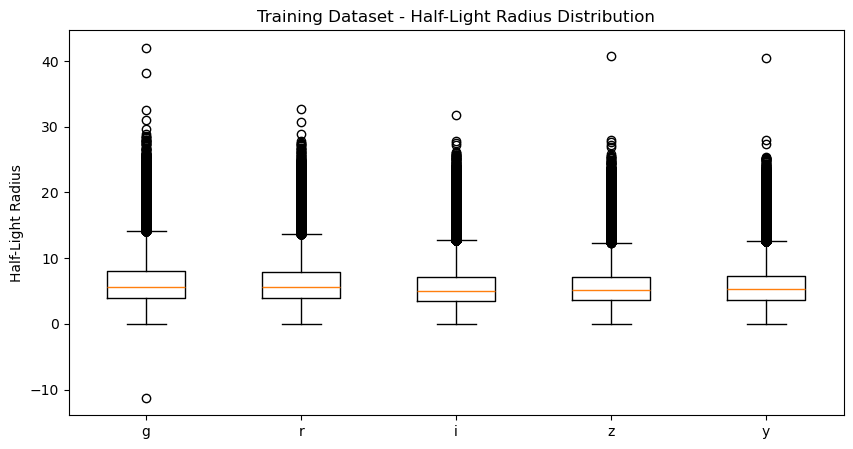

In [20]:
# Use boxplots to identify potential outliers in half-light radius

radius_cols = [f"{b}_half_light_radius" for b in bands]

plt.figure(figsize=(10,5))

plt.boxplot(
    [df_train[col] for col in radius_cols],
    labels=bands
)

plt.ylabel("Half-Light Radius")
plt.title("Training Dataset - Half-Light Radius Distribution")

plt.show()

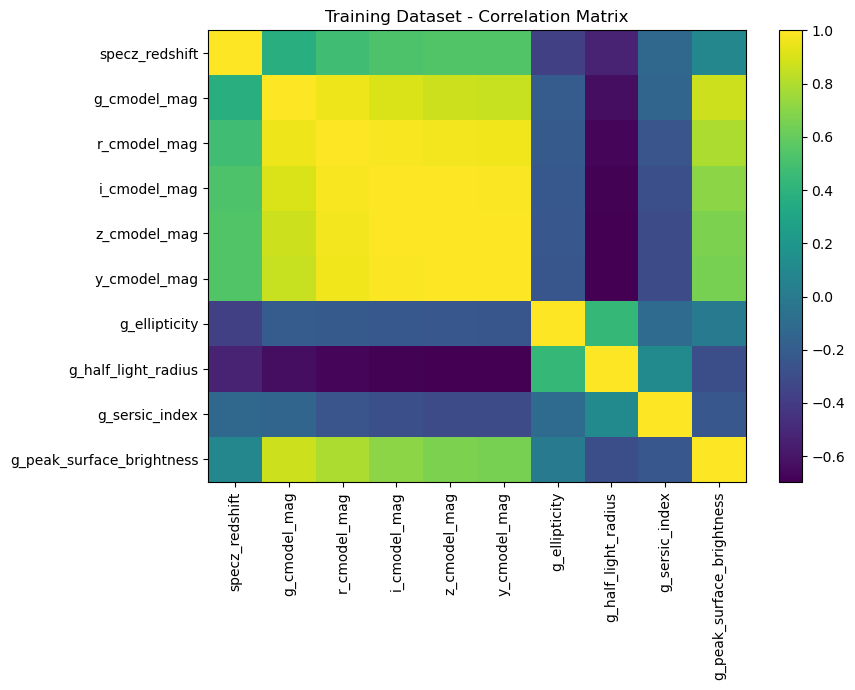

In [21]:
# Select important astronomical features for correlation analysis

corr_features = [
    "specz_redshift",
    "g_cmodel_mag",
    "r_cmodel_mag",
    "i_cmodel_mag",
    "z_cmodel_mag",
    "y_cmodel_mag",
    "g_ellipticity",
    "g_half_light_radius",
    "g_sersic_index",
    "g_peak_surface_brightness"
]

# Calculate the correlation matrix

corr_train = df_train[corr_features].corr()

# Visualize correlations between the selected astronomical features

plt.figure(figsize=(9,7))

plt.imshow(corr_train, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(corr_train.columns)),
    corr_train.columns,
    rotation=90
)

plt.yticks(
    range(len(corr_train.columns)),
    corr_train.columns
)

plt.title("Training Dataset - Correlation Matrix")

plt.tight_layout()
plt.show()

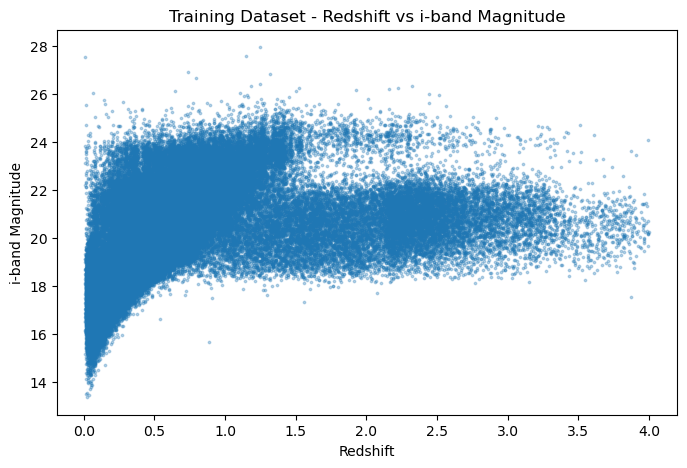

In [22]:
# Examine the relationship between redshift and i-band magnitude

plt.figure(figsize=(8,5))

plt.scatter(
    df_train["specz_redshift"],
    df_train["i_cmodel_mag"],
    s=3,
    alpha=0.3
)

plt.xlabel("Redshift")
plt.ylabel("i-band Magnitude")
plt.title("Training Dataset - Redshift vs i-band Magnitude")

plt.show()

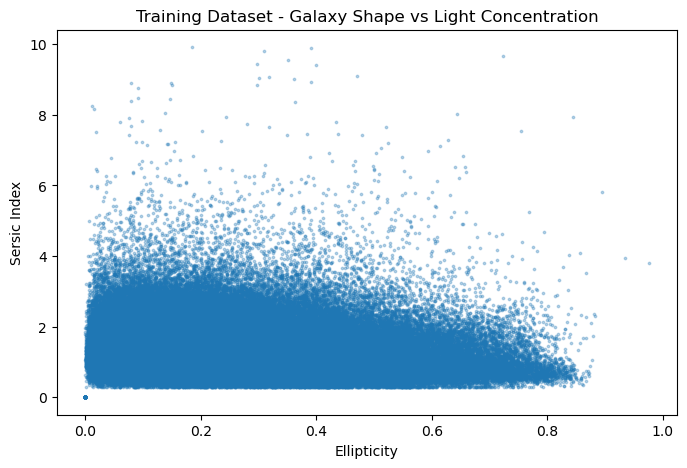

In [23]:
# Examine the relationship between galaxy shape and light concentration

plt.figure(figsize=(8,5))

plt.scatter(
    df_train["g_ellipticity"],
    df_train["g_sersic_index"],
    s=3,
    alpha=0.3
)

plt.xlabel("Ellipticity")
plt.ylabel("Sersic Index")
plt.title("Training Dataset - Galaxy Shape vs Light Concentration")

plt.show()

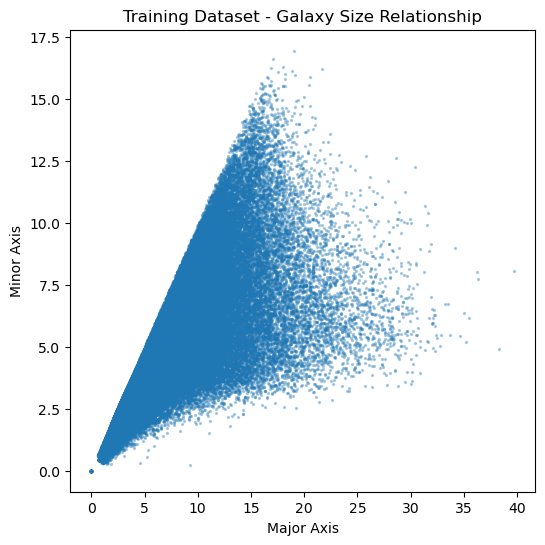

In [24]:
# Examine the relationship between the major and minor axes of galaxies

plt.figure(figsize=(6,6))

plt.scatter(
    df_train["g_major_axis"],
    df_train["g_minor_axis"],
    s=2,
    alpha=0.3
)

plt.xlabel("Major Axis")
plt.ylabel("Minor Axis")
plt.title("Training Dataset - Galaxy Size Relationship")

plt.show()

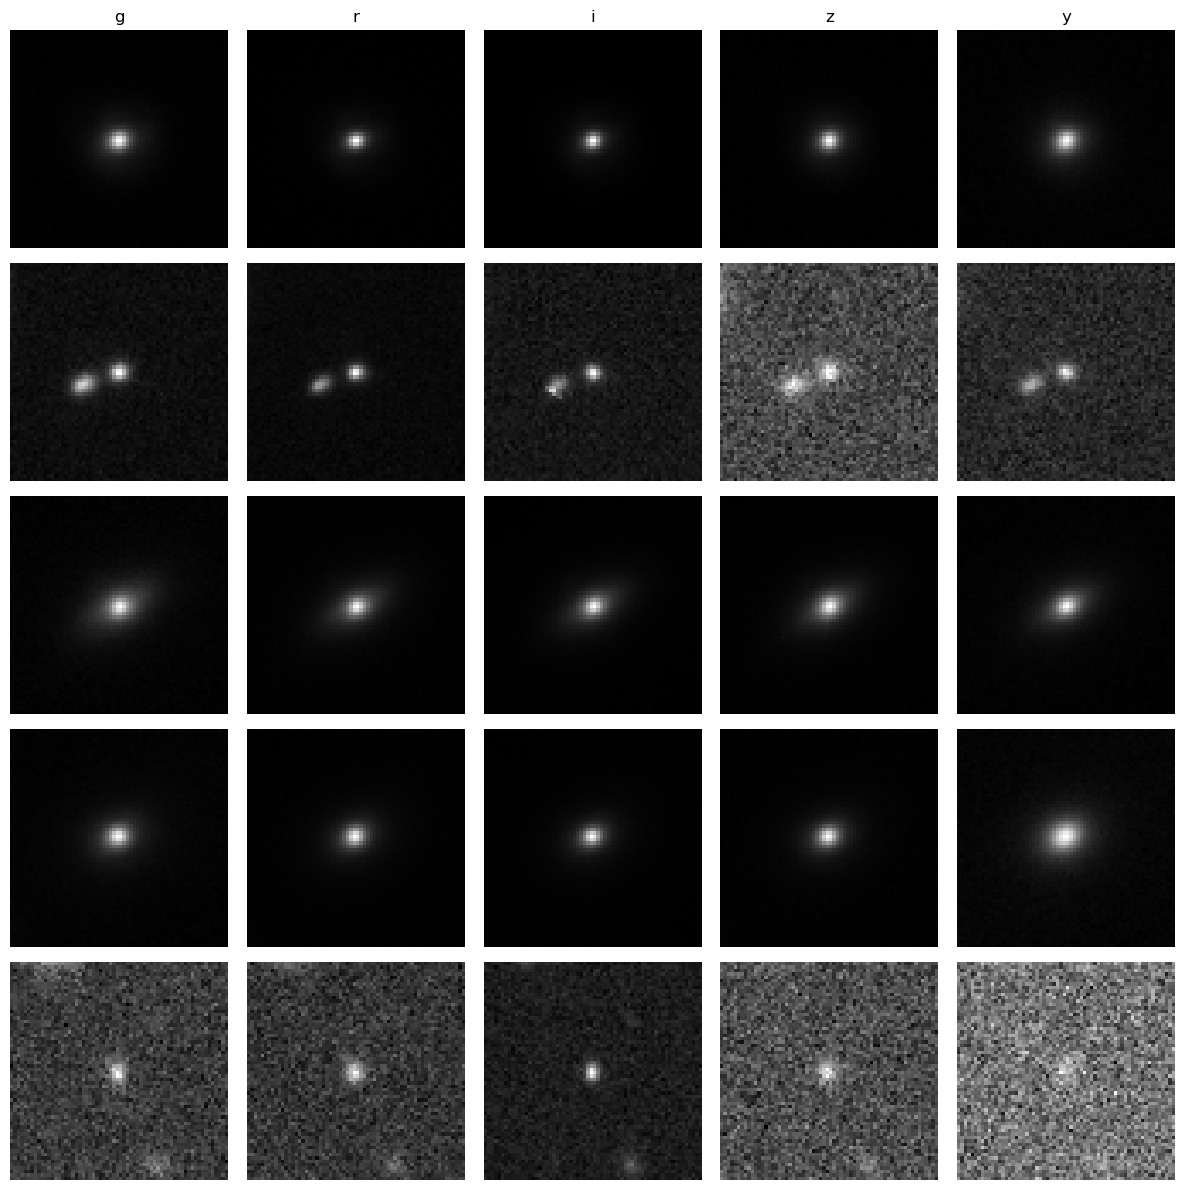

In [25]:
# Select a small number of random galaxies for image visualization
# Only the selected images are loaded to avoid excessive memory usage

with h5py.File(training_path, "r") as f:
    idx_train = sorted(
        random.sample(range(len(df_train)), 5)
    )
    
    images_train = f["image"][idx_train]
# Display the five photometric bands for the selected training galaxies

fig, axes = plt.subplots(5, 5, figsize=(12, 12))

for row in range(5):
    for col in range(5):
        axes[row, col].imshow(
            images_train[row, col],
            cmap="gray"
        )
        
        axes[row, col].axis("off")
        
        if row == 0:
            axes[row, col].set_title(bands[col])

plt.tight_layout()
plt.show()

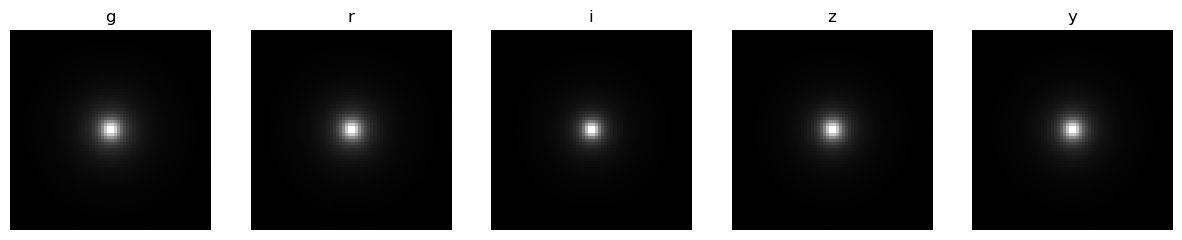

In [26]:
# Calculate the average image for each photometric band
# Images are processed in batches to avoid loading the entire dataset

num_train = len(df_train)

mean_band_train = np.zeros((5, 64, 64))

with h5py.File(training_path, "r") as f:
    images = f["image"]

    for start in range(0, num_train, 500):
        end = min(start + 500, num_train)
        batch = images[start:end]
        
        mean_band_train += batch.sum(axis=0)

mean_band_train /= num_train
# Display the average galaxy image for each photometric band

fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i, band in enumerate(bands):
    axes[i].imshow(
        mean_band_train[i],
        cmap="gray"
    )
    
    axes[i].set_title(band)
    axes[i].axis("off")

plt.show()

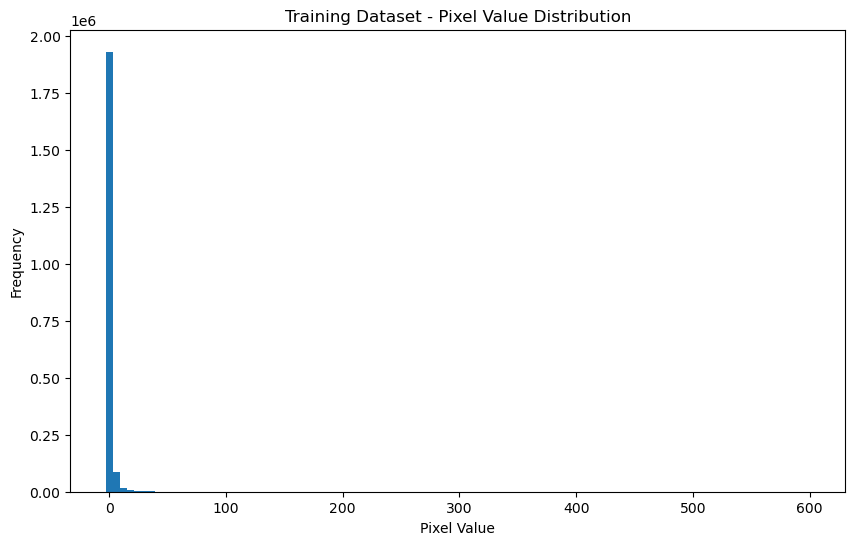

In [27]:
# Load a small sample of training images to examine pixel values
# Only 100 galaxies are loaded instead of the complete image dataset

with h5py.File(training_path, "r") as f:
    sample_pixels_train = f["image"][:100]
# Plot the distribution of pixel values in the sampled training images

plt.figure(figsize=(10,6))

plt.hist(
    sample_pixels_train.flatten(),
    bins=100
)

plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.title("Training Dataset - Pixel Value Distribution")

plt.show()

In [33]:
# Calculate the average pixel brightness for each photometric band
# Images are processed in batches to reduce memory usage

band_means_train = []

with h5py.File(training_path, "r") as f:
    images = f["image"]

    for b in range(5):
        total = 0
        count = 0

        for start in range(0, num_train, 500):
            end = min(start + 500, num_train)
            batch = images[start:end, b]
            
            total += batch.mean()
            count += 1

        band_means_train.append(total / count)


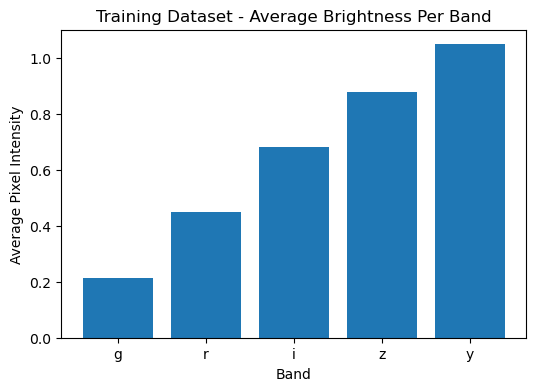

In [34]:
# Compare the average pixel brightness across the five photometric bands

plt.figure(figsize=(6,4))

plt.bar(bands, band_means_train)

plt.xlabel("Band")
plt.ylabel("Average Pixel Intensity")
plt.title("Training Dataset - Average Brightness Per Band")

plt.show()

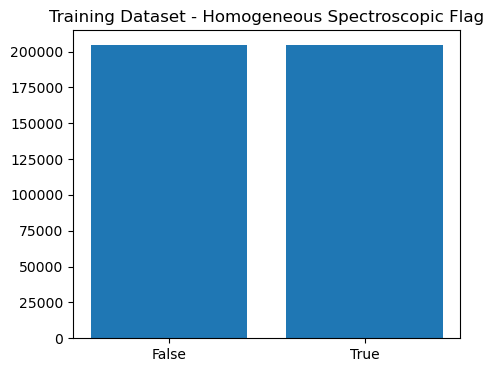

specz_flag_homogeneous
True    204573
Name: count, dtype: int64


In [30]:
# Analyze the distribution of the homogeneous spectroscopic flag

counts_train = df_train["specz_flag_homogeneous"].value_counts()

plt.figure(figsize=(5,4))

plt.bar(
    ["False", "True"],
    counts_train.values
)

plt.title("Training Dataset - Homogeneous Spectroscopic Flag")

plt.show()

print(counts_train)

In [31]:
# Display the most frequent spectroscopic source names

df_train["specz_name"].value_counts().head(10)

specz_name
b'SDSS-DR12-1237679340566282311'         1
b'SDSS-DR14-9867557056004726784'         1
b'WIGGLEZ-DR1-S00J231922821+00014156'    1
b'SDSS-DR12-1237663784192966798'         1
b'SDSS-DR12-1237663784192901350'         1
b'SDSS-DR14-9866525713711996928'         1
b'SDSS-DR12-1237666408437973348'         1
b'SDSS-DR12-1237663784192901254'         1
b'SDSS-DR12-1237663784192966858'         1
b'SDSS-DR12-1237663784192901384'         1
Name: count, dtype: int64

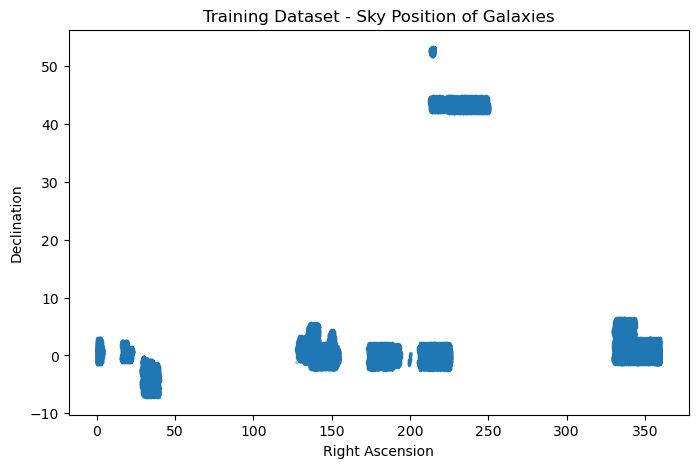

In [32]:
# Visualize the spatial distribution of training galaxies
# using right ascension and declination

plt.figure(figsize=(8,5))

plt.scatter(
    df_train["ra"],
    df_train["dec"],
    s=2,
    alpha=0.3
)

plt.xlabel("Right Ascension")
plt.ylabel("Declination")
plt.title("Training Dataset - Sky Position of Galaxies")

plt.show()

Number of numerical columns: 81


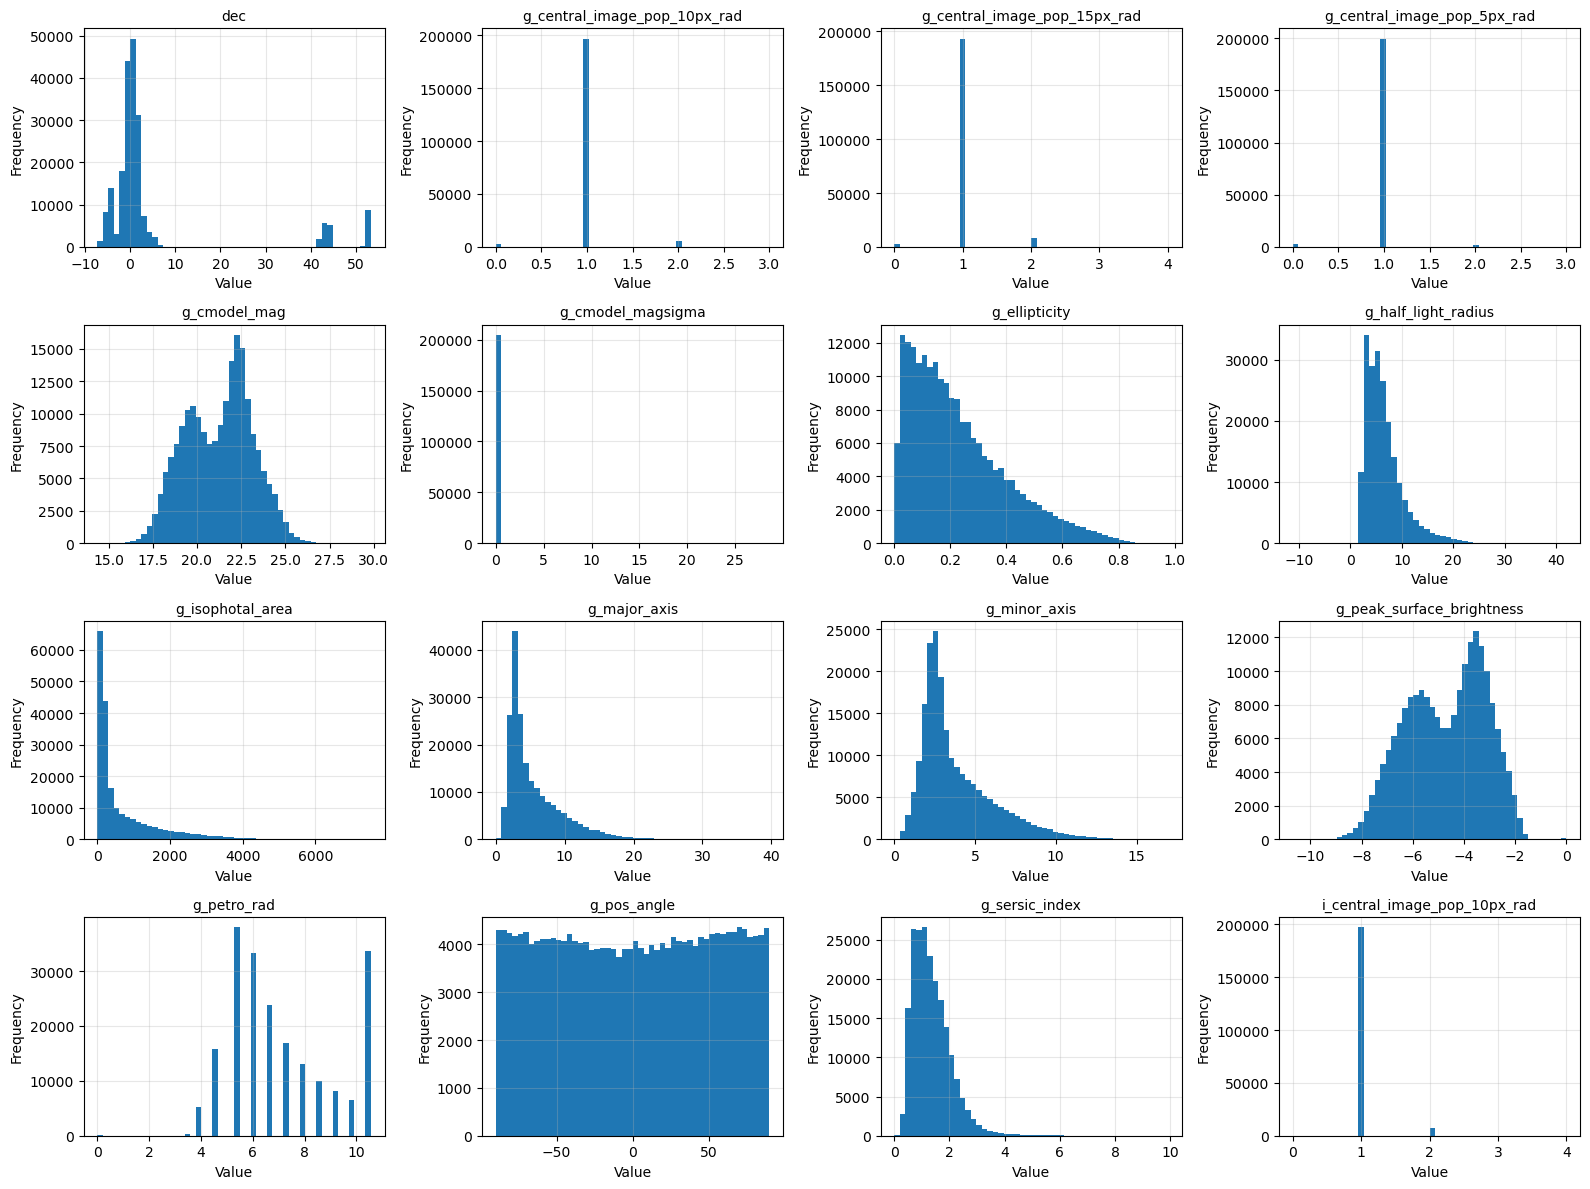

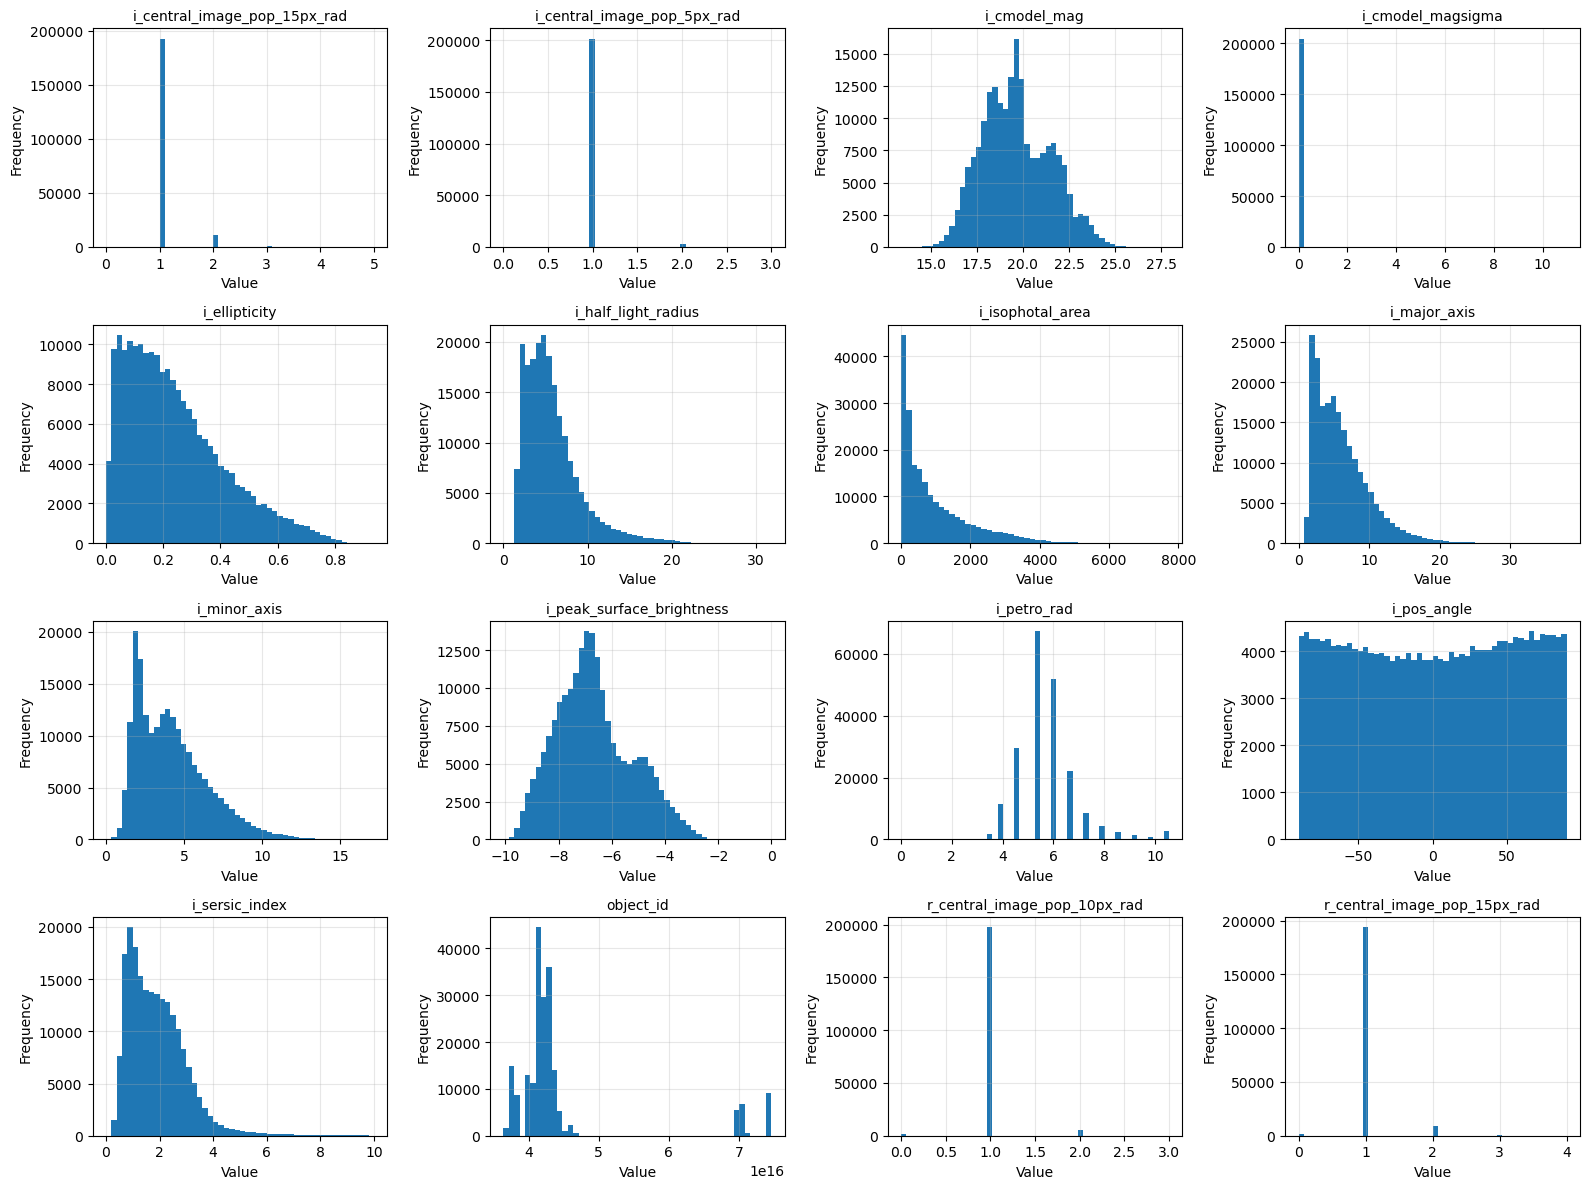

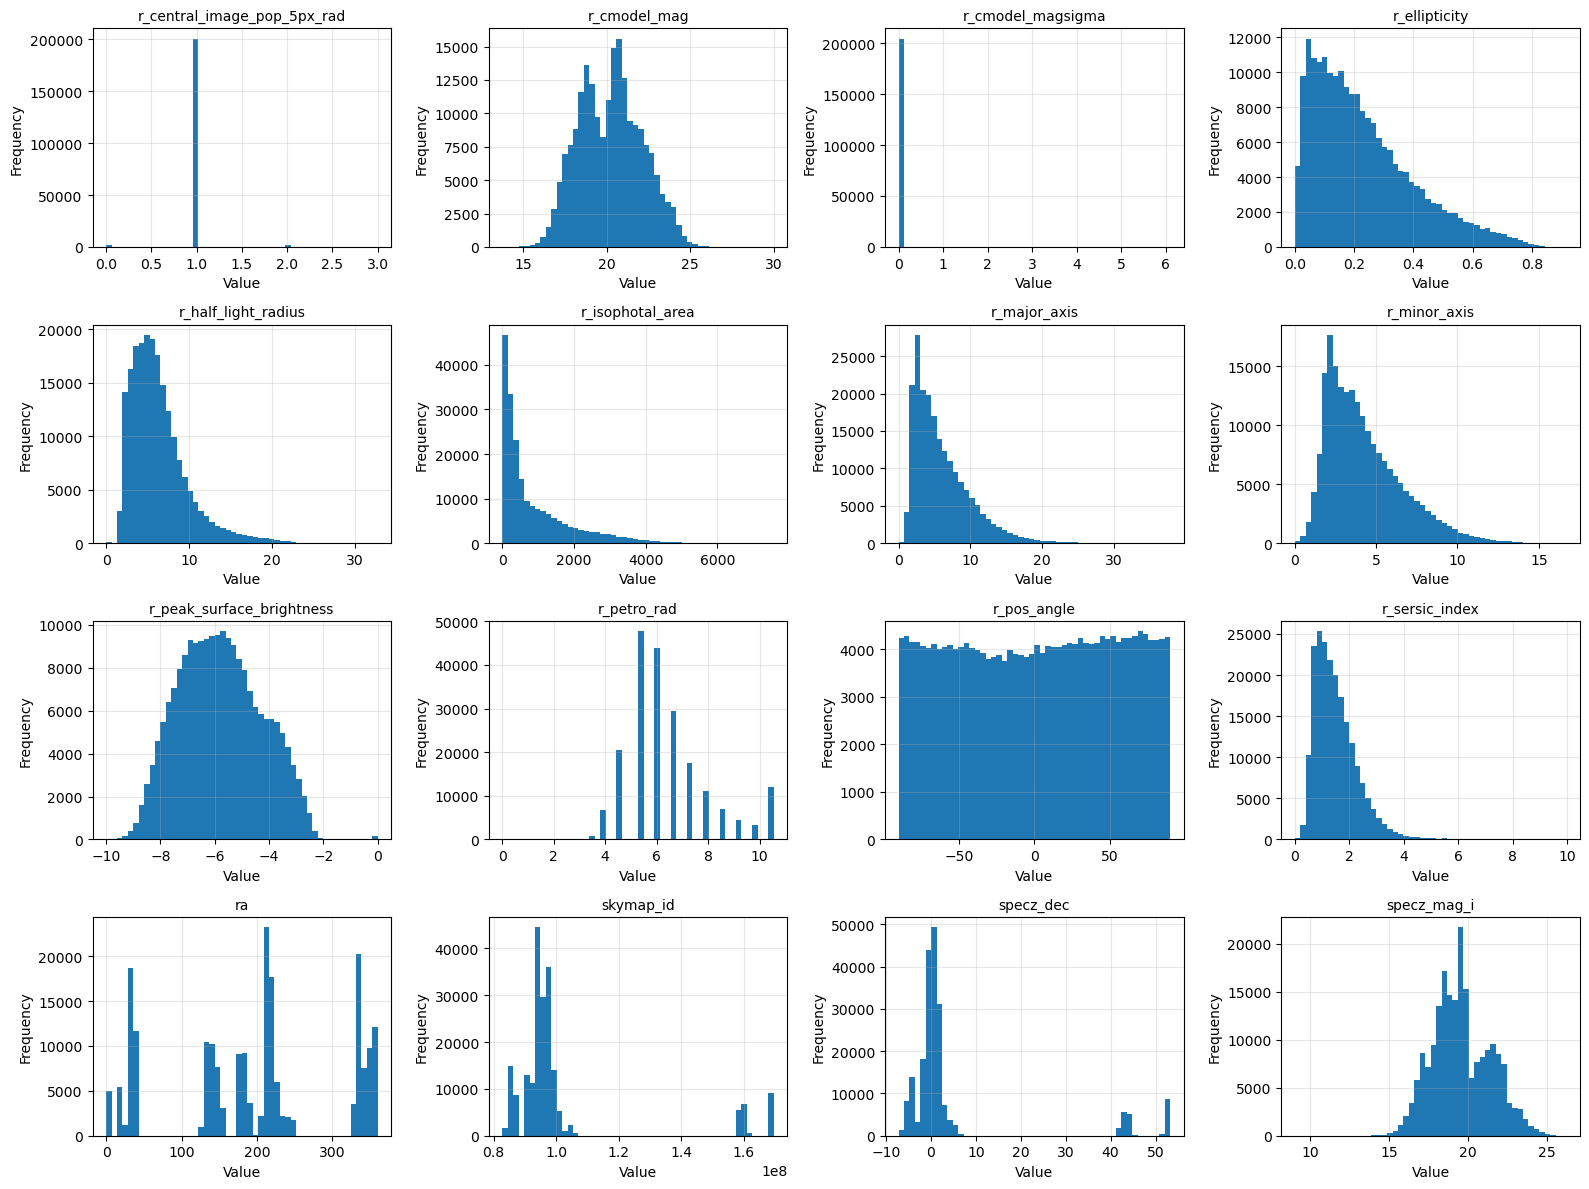

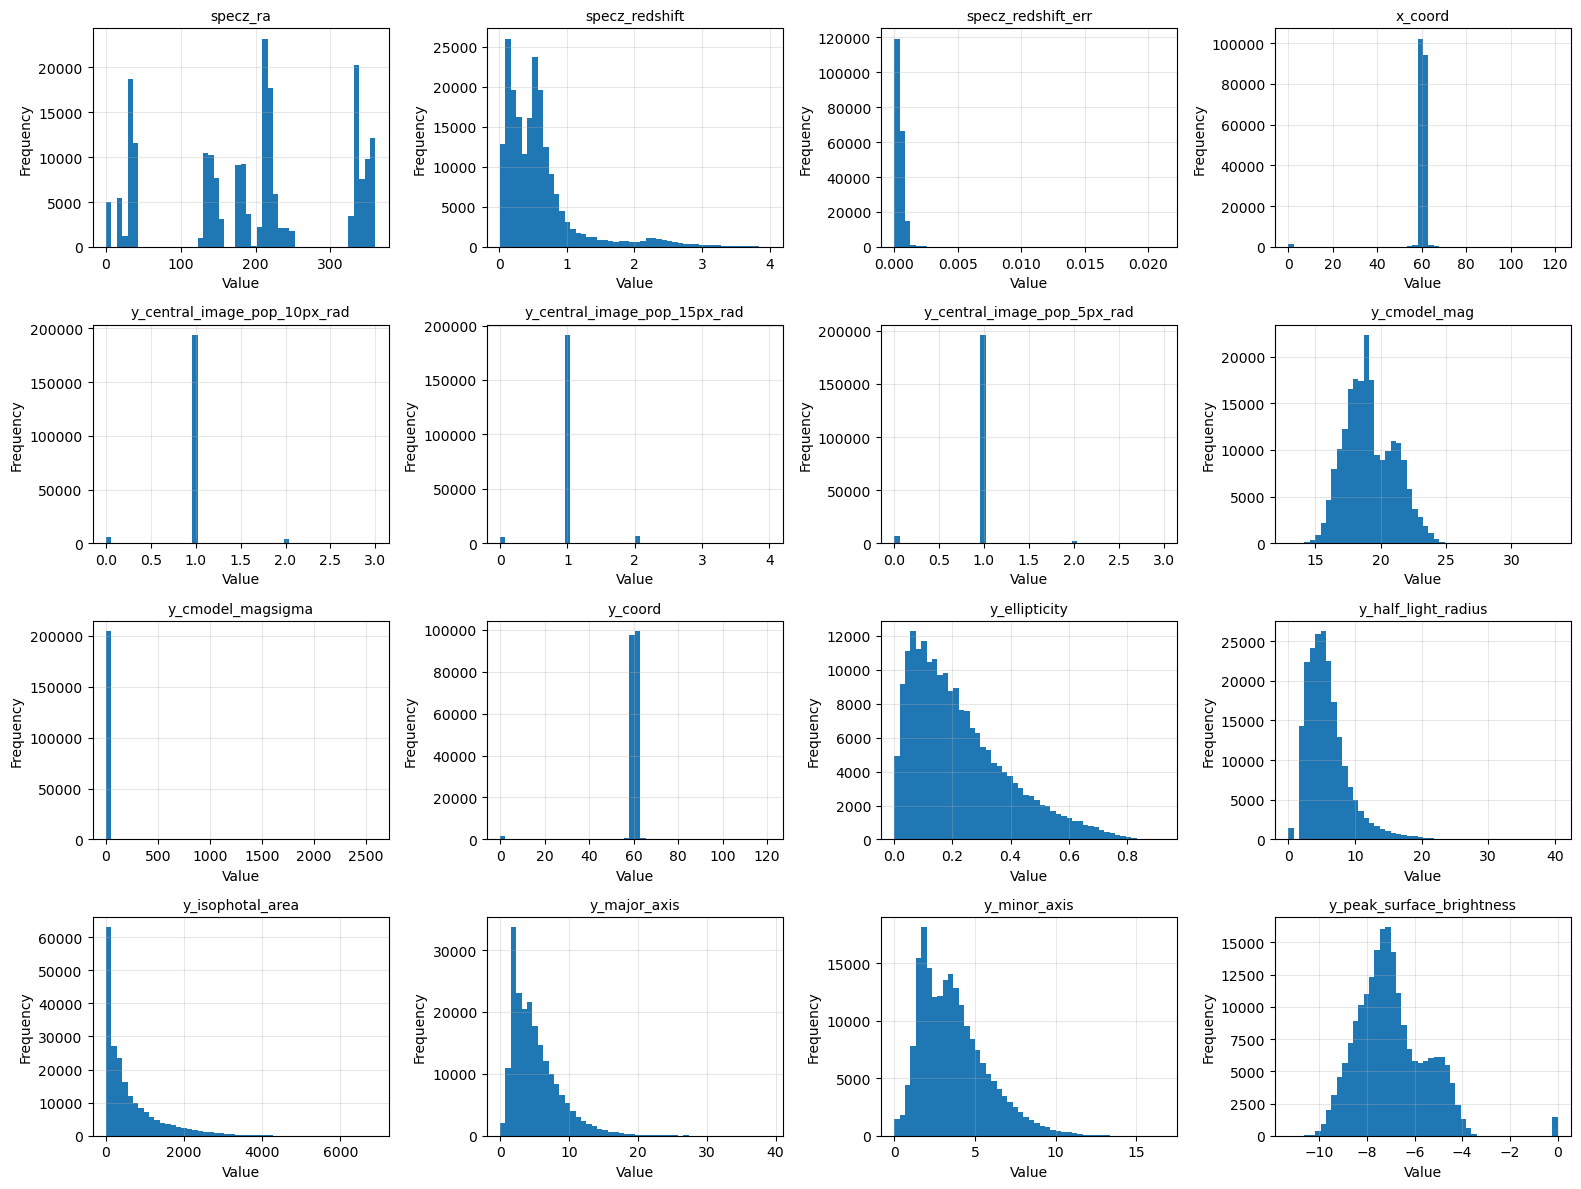

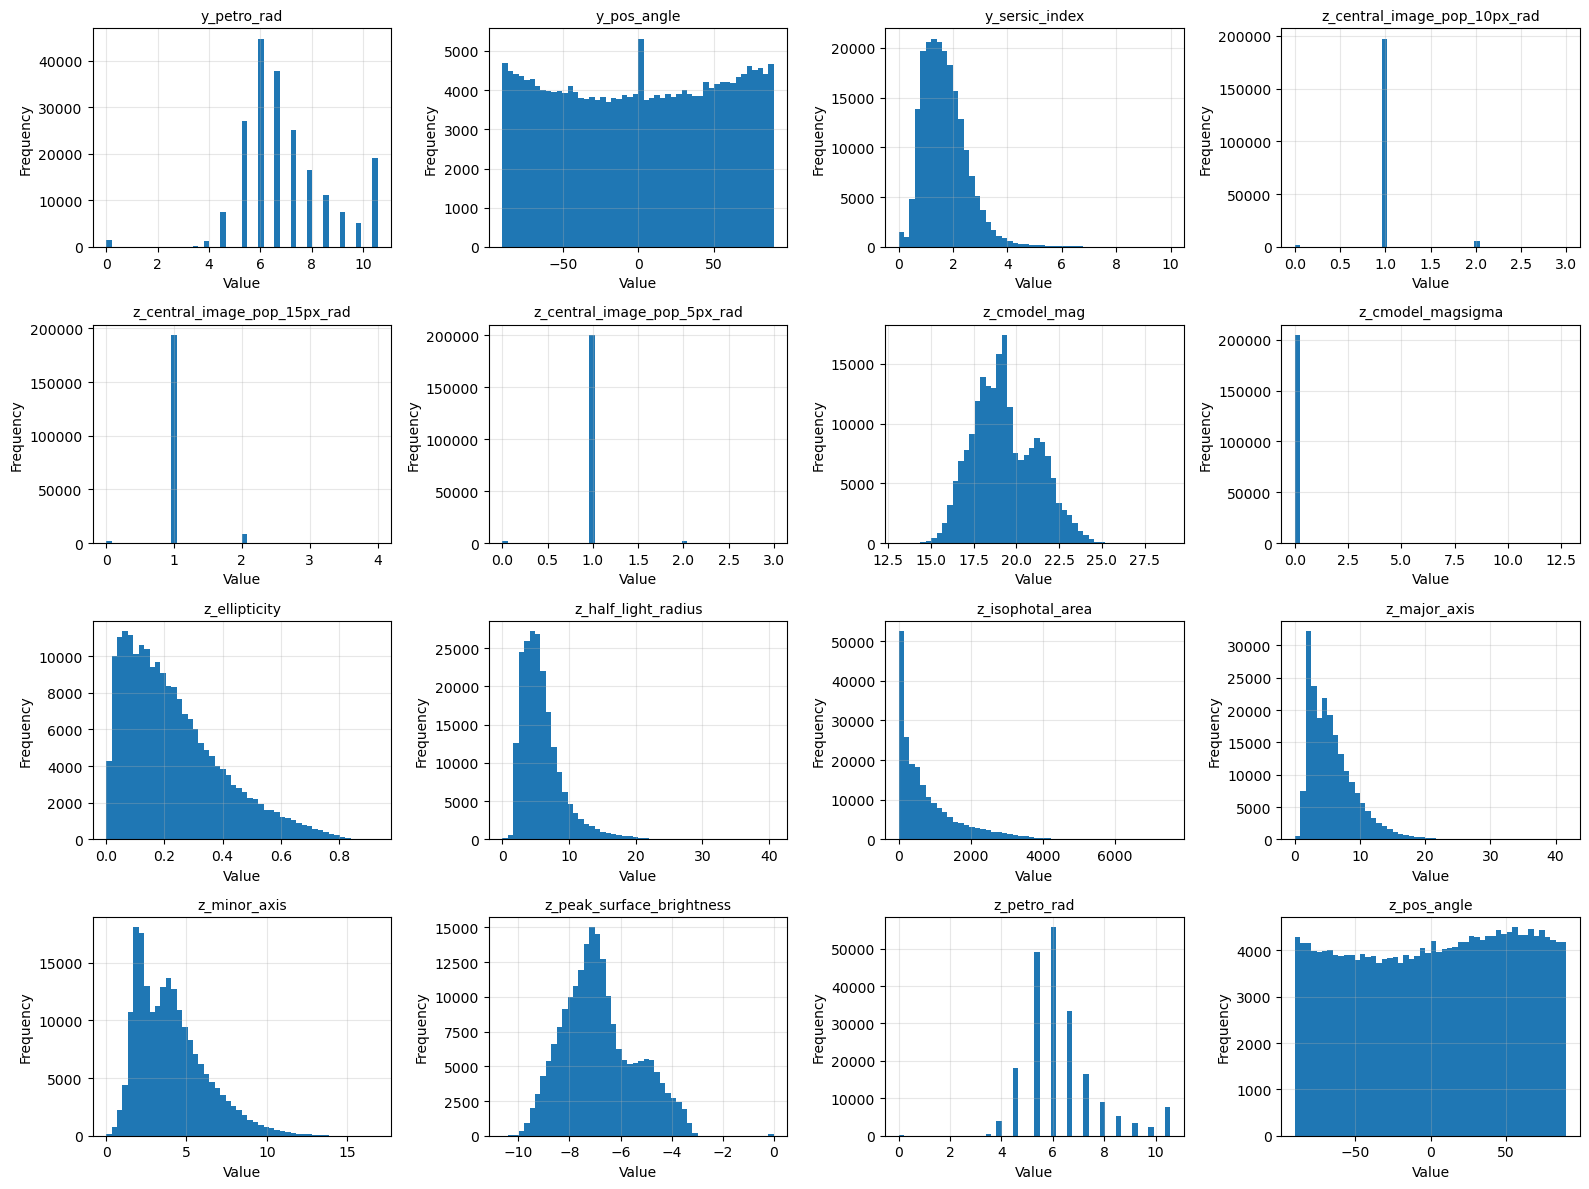

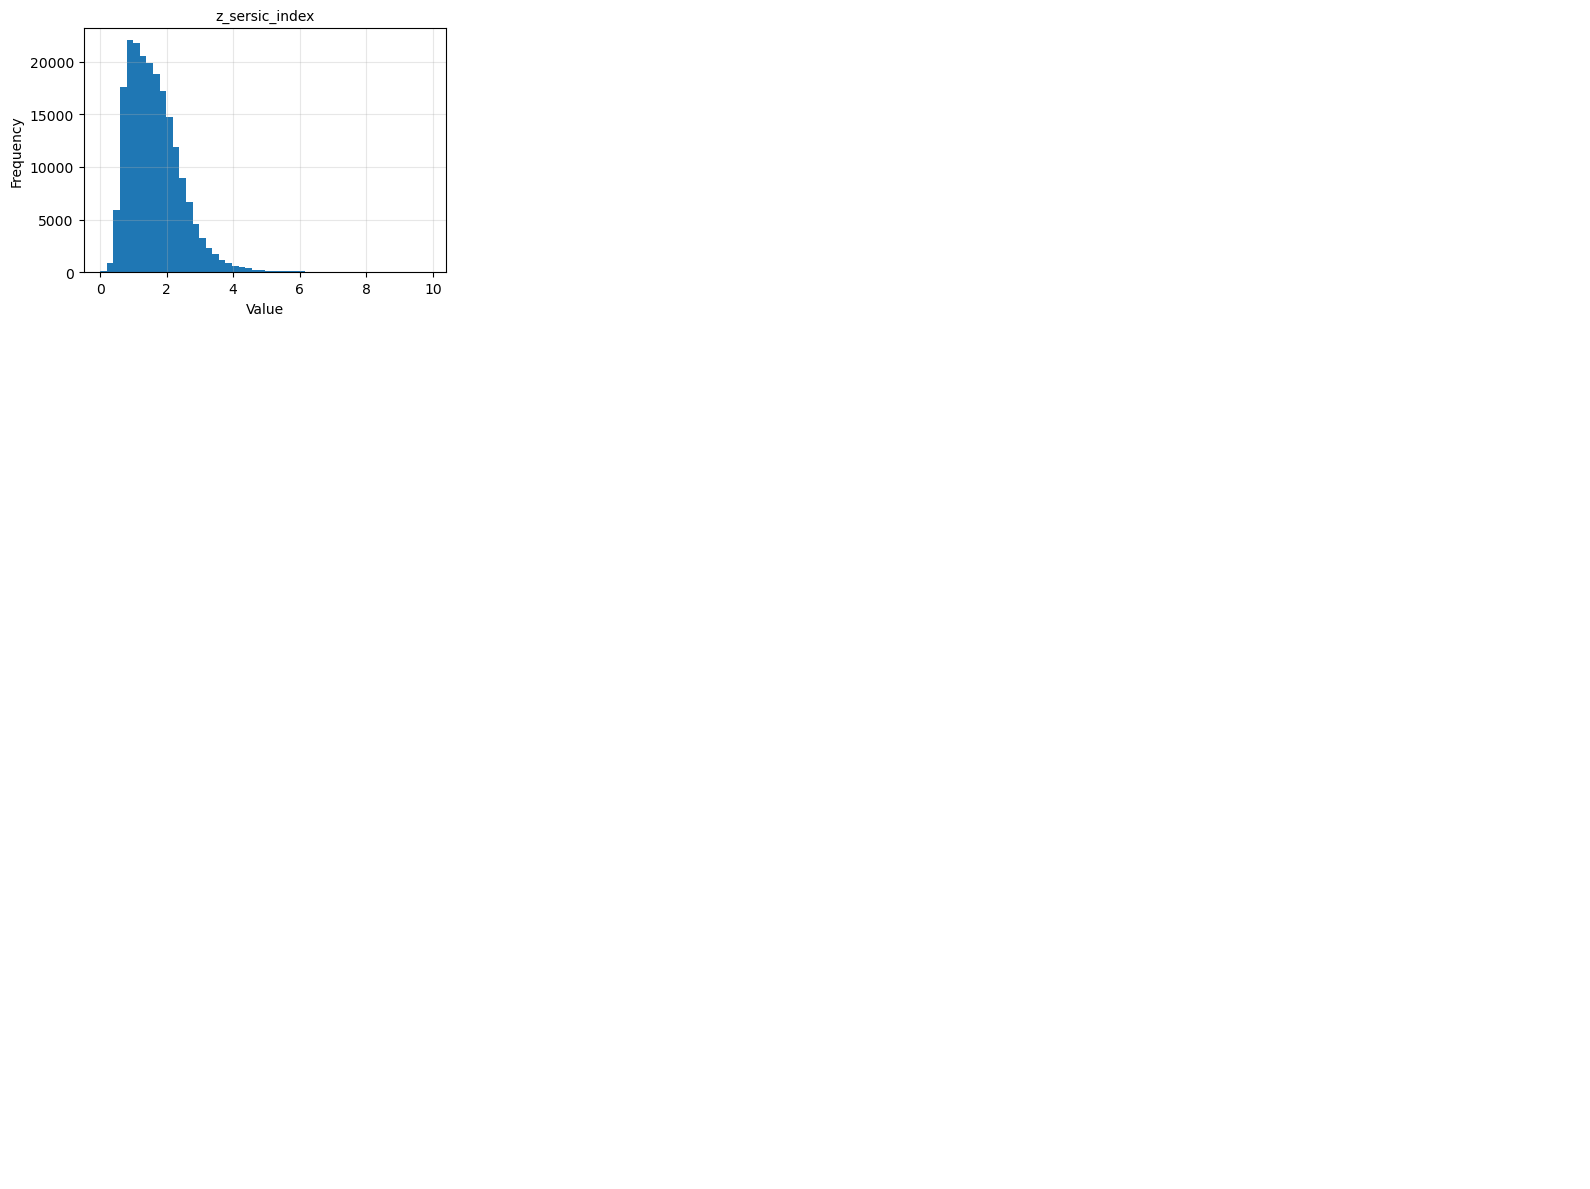

In [7]:
# Plot histogram for every numerical column in the 64x64 training dataset

import math

# Select numerical columns only
numeric_train = df_train.select_dtypes(include=np.number)

columns = numeric_train.columns
n_cols = 4
n_rows = 4

print("Number of numerical columns:", len(columns))

# Plot 16 histograms per figure
for start in range(0, len(columns), n_cols * n_rows):

    batch_columns = columns[start:start + n_cols * n_rows]

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 12))
    axes = axes.flatten()

    for i, column in enumerate(batch_columns):
        axes[i].hist(
            numeric_train[column].dropna(),
            bins=50
        )

        axes[i].set_title(column, fontsize=10)
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Frequency")
        axes[i].grid(alpha=0.3)

    # Hide unused plots
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()